# <img src="./logo_UTN.svg" align="right" width="150" /> 

#### Teoría de Circuitos II

# Tarea Semanal 3

Autor: Lopez Cruz Juan Carlos


# Introducción

Diseñar un filtro pasabajos **Bessel**  para aproximar un Retardo de Grupo $D(\omega)$ constante en banda de paso que cumpla con la siguiente plantilla:

<img src="./plantilla_ts3.png" /> 

## Items a tratar de la platilla:

1. Utilizando el método de Storch ( pag. 403 del Schaumann ) obtener la $T(s)$ Bessel de orden **N = 2, 3 y 4**.

2. Elegir la $T(s)$ con el mínimo orden que cumple con $\alpha_{max} = 1dB$

3. Evaluar el Retardo de Grupo $D(2.5)$. Expresar en forma porcentual [%] el error o desviamiento respecto a $D(0)$

4. Sintetizar el circuito normalizado con estructuras Sallen-Key con K=1 ( realimentación negativa unitaria )   

<img src="./circuito_sallen_key.png" />

## Items bonus:

1.  Simulación numérica en python utilizando la función pretty_print_lti( num, den ) para el 1)
2.  Desnormalizar los componentes para obtener un $D(0) = 200microseg$.
3.  Simulación Circuital con los valores desnormalizados. Medir el $D(\omega)$ resultante (*) indicar con un marker el $\Delta D(\omega)$ en banda de paso.

(*) Para medir el $D(\omega)$ en LTSpice, click derecho en el y Axis de la phase y seleccionar "Group Delay"

<img src="./group_delay.png" />

## Resolucion:

### Respuesta de un filtro tipo Bessel

En este caso ya tenemos nuestra plantilla normalizada por lo que procedemos a calcular la transferencia usando el método de Storch.

$$
T(s) = \frac{K}{senh(s) + cosh(s)}
$$

Sacamos como factor $senh(s)$ del denominador por lo que nos queda de la siguiete forma

$$
T(s) = \frac{K}{senh(s) \cdot (1 + \frac{cosh(s)}{senh(s)}}
$$

Como $coth(s) = \frac{cosh(s)}{senh(s)}$:

$$
T(s) = \frac{K \cdot \frac{1}{senh(s)}}{1 + coth(s)}
$$

La $coth(s)$ lo calculamos mediate la siguiente sucesion.

$$
coth(s) = \frac{cosh(s)}{senh(s)} = \frac{1}{s} + \frac{1}{\frac{3}{s} + \frac{1}{\frac{5}{s} + \frac{1}{...}}}
$$

Mediante esta sucesion podemos calcular la $coth(s)$ donde cortaremos la sucecion de acuerdo al n.

### Obtencion de la Transferencia

Procedemos a calcular las transferecias para n = 2, 3 y 4.

Para n = 2:

$$
coth(s) = \frac{1}{s} + \frac{1}{\frac{3}{s}} = \frac{1}{s} + \frac{s}{3} = \frac{s^2 + 3}{3s}
$$

$$
\Rightarrow T_2(s) = \frac{K}{s^2 + 3s + 3}
$$

Arbitrariamente para todos los casos elegiremos que $K = \omega_o^2$, por lo que nuestra transferencia queda de la siguiente manera.

$$
\Rightarrow T_2(s) = \frac{3}{s^2 + 3s + 3}
$$

Para n = 3

$$
coth(s) = \frac{1}{s} + \frac{1}{\frac{3}{s} + \frac{1}{\frac{5}{s}}} = \frac{1}{s} + \frac{1}{\frac{3}{s} + \frac{s}{5}} = \frac{1}{s} + \frac{1}{\frac{s^2 + 15}{5s}} = \frac{1}{s} + \frac{5s}{s^2 + 15} = \frac{s^2 + 5s^2 + 15}{s^3 + 15s} = \frac{6s^2 + 15}{s^3 + 15s}
$$

$$
\Rightarrow T_3(s) = \frac{15}{s^3 + 6s^2 + 15s + 15}
$$

Para n = 4

$$
coth(s) = \frac{1}{s} + \frac{1}{\frac{3}{s} + \frac{1}{\frac{5}{s} + \frac{1}{\frac{7}{s}}}} = \frac{1}{s} + \frac{1}{\frac{3}{s} + \frac{1}{\frac{5}{s} + \frac{s}{7}}} = \frac{1}{s} + \frac{1}{\frac{3}{s} + \frac{1}{\frac{s^2 + 35}{7s}}} = \frac{1}{s} + \frac{1}{\frac{3}{s} + \frac{7s}{s^2 + 35}} = \frac{1}{s} + \frac{1}{\frac{3s^2 + 7s^2 + 105}{s^3 + 35s}} = \frac{1}{s} + \frac{s^3 + 35s}{10s^2 + 105}
$$

$$
\Rightarrow coth(s) = \frac{s^4 + 35s^2 + 10s^2 + 105}{10s^3 + 105s} = \frac{s^4 + 45s^2 + 105}{10s^3 + 105s}
$$

$$
\Rightarrow T_4(s) = \frac{105}{s^4 + 10s^3 + 45s^2 + 105s + 105}
$$

### Verificacion mediante pretty_print_lti( num, den )

Procedemos a verficar nuestras transferecias obtenidas de cada orden usando la funcion pretty_print_lti( num, den ) en python.

In [23]:
# Módulos numéricos y de funciones científicas
import numpy as np
from scipy import signal as sig
import sympy as sp
from IPython.display import display, Math

# Módulos para los gráficos
import matplotlib as mpl
from matplotlib import pyplot as plt

# Funciones de PyTC2
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys
import pytc2.sistemas_lineales as pysist

Para n = 2:

In [25]:
#Orden
N=2

#Parametros del filtro
num,den = sig.bessel( N , 1 , analog=True, norm='delay', output='ba')

#Mostrar
pysist.pretty_print_lti(num,den)

<IPython.core.display.Math object>

Para n = 3

In [51]:
#Orden
N=3

#Parametros del filtro
num,den = sig.bessel( N , 1 , analog=True, norm='delay', output='ba')

#Mostrar
pysist.pretty_print_lti(num,den)

<IPython.core.display.Math object>

Para n = 4

In [54]:
#Orden
N=4

#Parametros del filtro
num,den = sig.bessel( N , 1 , analog=True, norm='delay', output='ba')

#Mostrar
pysist.pretty_print_lti(num,den)

<IPython.core.display.Math object>

### Seleccion de la Transferencia $T(s)$

Procemos a seleccionar la transferencia a usar de acuerdo con las especificaiones de nuestra plantilla, siendo en este caso $\alpha_{max} = 1dB$

Para n = 2.

$$
T_2(s) = \frac{3}{s^2 + 3s + 3}
$$

$$
T_2(j\omega) = \frac{3}{(j\omega)^2 + 3j\omega + 3} = \frac{3}{3 -\omega^2 + 3j\omega}
$$

$$
|T_2(\omega)| = \frac{3}{\sqrt{(3 -\omega^2)^2 + 9\omega^2}} \Rightarrow |T_2(1)| = \frac{3}{\sqrt{(3 -1^2)^2 + 9 \cdot 1^2}}
$$

$$
|T_2(1)| = 0.832
$$

$$
\alpha dB(1) = -20\log(0.832) = 1.597dB
$$

Como $\alpha dB(1) > 1dB$, esta transferencia no cumple con la plantilla ya que supera el $\alpha_{max}$.

Para n = 3.

$$
T_3(s) = \frac{15}{s^3 + 6s^2 + 15s + 15}
$$

$$
T_3(j\omega) = \frac{15}{(j\omega)^3 + 6(j\omega)^2 + 15j\omega + 15} = \frac{15}{15 -6\omega^2 + 15j\omega -j\omega^3} = \frac{15}{15 -6\omega^2 +j\omega(15 - \omega^2)}
$$

$$
|T_3(\omega)| = \frac{15}{\sqrt{(15 -6\omega^2)^2 + (\omega(15 - \omega^2))^2}} \Rightarrow |T_3(1)| = \frac{15}{\sqrt{(15 -6 \cdot 1^2)^2 + (1(15 - 1^2))^2}}
$$

$$
|T_3(1)| = 0.901
$$

$$
\alpha dB(1) = -20\log(0.901) = 0.905dB
$$

Como $\alpha dB(1) < 1dB$, esta transferencia cumple con la plantilla ya que es inferior a $\alpha_{max}$.

Para n = 4.

$$
T_4(s) = \frac{105}{s^4 + 10s^3 + 45s^2 + 105s + 105}
$$

$$
T_4(j\omega) = \frac{105}{(j\omega)^4 + 10(j\omega)^3 + 45(j\omega)^2 + 105j\omega + 105} = \frac{105}{105 -45\omega^2 + \omega^4 + 105j\omega - 10j\omega^3} = \frac{105}{105 + \omega^2(\omega^2 - 45) + j\omega(105 + 10\omega^2)}
$$

$$
|T_4(\omega)| = \frac{105}{\sqrt{(105 + \omega^2(\omega^2 - 45))^2 + (\omega(105 + 10\omega^2))^2}} \Rightarrow |T_4(1)| = \frac{105}{\sqrt{(105 + 1^2(1^2 - 45))^2 + (1(105 + 10 \cdot 1^2))^2}}
$$

$$
|T_4(1)| = 0.93
$$

$$
\alpha dB(1) = -20\log(0.93) = 0.63dB
$$

Como $\alpha dB(1) < 1dB$, esta transferencia cumple con la plantilla ya que es inferior a $\alpha_{max}$.

Para seleccionar tomaremos en cuenta cual cumple, con el minimo orden, con los requerimientos de nuestra plantilla, por lo tanto seleccionamos el orden como nuestra transferencia sera la de n = 3.

$$
T(s) = \frac{15}{s^3 + 6s^2 + 15s + 15}
$$

Ahora procedemos a separar las secciones en una de segundo orden y otra de primer orden.

In [28]:
#Denominador de la transferencia

den = np.roots([1,6,15,15])

#Redondeo a 4 decimales
roots = np.round(raices,4)

#Muestro los polos
for i, r in enumerate(roots):
    print(f"Polo {i+1} = {r.real} + {r.imag}")

#Coeficientes de las secciones
pol1 = np.array([roots[0], roots[1]])
pol2 = roots[2]

print(np.round(np.poly(pol1),4))
print(np.abs(pol2))

Polo 1 = -1.8389 + 1.7544
Polo 2 = -1.8389 + -1.7544
Polo 3 = -2.3222 + 0.0
[1.     3.6778 6.4595]
2.3222


Por lo tanto nuestra transferecia queda de la siguiente manera.

$$
T(s) = \frac{2.3222}{s + 2.3222}\frac{6.4595}{s^2 + s 3.6778 + 6.4595}
$$

### Analisis del retardo de grupo $D(\omega)$

Ya con nuestra transferecia seleccionada analizaremos el retardo de grupo en $D(2.5)$, para ello usaremos la siguiente expresion.

$$
D(\omega) = \sum_{i=1}^{n} \frac{-\sigma_i}{\sigma_i^2 + (\omega - \omega_i)^2}
$$

Donde $\sigma_i$ es la parte real de un polo y $\omega_i$ es la parte imaginaria de un polo.

En la transferencia $T(s)$ tenemos 3 polos:

$$
P_1 = -2.3222 + j0
$$

$$
P_{2,3} = -1.8389 \pm j1.7544
$$

Por lo que $D(\omega)$ queda de la siguiente manera.

$$
D(\omega) = \frac{2.3222}{(-2.3222)^2 + \omega^2} + \frac{1.8389}{(-1.8389)^2 + (\omega - 1.7544)^2} + \frac{1.8389}{(-1.8389)^2 + (\omega + 1.7544)^2}
$$

Ahora analizaremos para $\omega = 2.5$ y $\omega = 0$.

$$
D(2.5) = 0.752
$$

$$
D(0) \approx 1
$$

Y el error porcentual queda:

$$
e = \left| \frac{D(2.5) - D(0)}{D(2.5)} \right| \cdot 100 = 32.97
$$

### Verificacion mediante python

A continuacion verificaremos los retardos obetenidos.

D3(2.5) = 0.7518
D3(0) = 1.0005
Error porcentual = 33.07 %


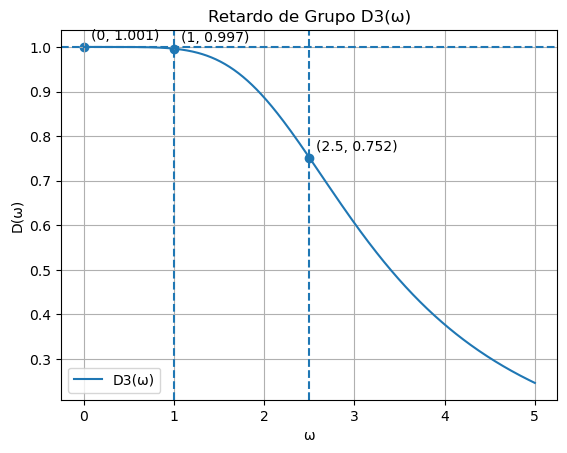

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Definimos la función
def D3(w):
    term1 = 2.32 / ((-2.32)**2 + w**2)
    term2 = 1.84 / ((-1.84)**2 + (w - 1.754)**2)
    term3 = 1.84 / ((-1.84)**2 + (w + 1.754)**2)
    return term1 + term2 + term3

# Valores importantes
w_points = [0, 1, 2.5]
D_points = [D3(w) for w in w_points]

D_2_5 = D3(w1)
D_0 = D3(w0)

print(f"D3(2.5) = {D_2_5:.4f}")
print(f"D3(0) = {D_0:.4f}")

# Error porcentual
error = abs((D_2_5 - D_0) / D_2_5) * 100
print(f"Error porcentual = {error:.2f} %")

# Curva
w = np.linspace(0, 5, 500)
D_vals = D3(w)

plt.figure()
plt.plot(w, D_vals, label="D3(ω)")

# Marcar puntos
plt.scatter(w_points, D_points)

# Etiquetas de los puntos
for w_val, d_val in zip(w_points, D_points):
    plt.annotate(f"({w_val}, {d_val:.3f})",
                 (w_val, d_val),
                 textcoords="offset points",
                 xytext=(5,5))

# Líneas guía
plt.axvline(1, linestyle='--')
plt.axvline(2.5, linestyle='--')
plt.axhline(D3(0), linestyle='--')

plt.title("Retardo de Grupo D3(ω)")
plt.xlabel("ω")
plt.ylabel("D(ω)")
plt.grid()
plt.legend()

plt.show()

### Transferecia de la topologia Sallen-Key

<img src="./circuito_sallen_key.png" />

Para ello primero empezaremos por el analisis de transferencia del circuito.

$$
V_o = V_x\frac{\frac{1}{sC2}}{\frac{1}{sC2} + R2} = V_x\frac{1}{sR2C2 + 1}
$$

$$
\Rightarrow V_x = V_o(sR2C2 + 1) (1)
$$

$$
\frac{(V_i - V_x)}{R1} = \frac{(V_x - V_o)}{R2} + \frac{(V_x - V_o)}{\frac{1}{sC1}} (2)
$$

(1) $\Rightarrow$ (2)

$$
\frac{(V_i - V_o(sR2C2 + 1))}{R1} = \frac{(V_o(sR2C2 + 1) - V_o)}{R2} + \frac{(V_o(sR2C2 + 1) - V_o)}{\frac{1}{sC1}}
$$

$$
\frac{V_i}{R1} = V_o(\frac{sR2C2}{R2} + (sR2C2) \cdot sC1 + \frac{sR2C2 + 1}{R1})
$$

$$
\frac{V_i}{R1} = V_o(\frac{sR1C2 + s^2R1R2C1C2 + sR2C2 + 1}{R1})
$$

$$
\Rightarrow H(s) = \frac{V_o}{V_i} = \frac{R1}{R1^2R2C1C2}\frac{1}{s^2 + s(\frac{C2(R1 + R2)}{R1R2C1C2}) + \frac{1}{R1R2C1C2}}
$$

$$
H(s) = \frac{\frac{1}{R1R2C1C2}}{s^2 + s(\frac{R1 + R2}{R1R2C1}) + \frac{1}{R1R2C1C2}}
$$

### Verificacion

Procedemos a verificar nuestra transferecia calculada

In [71]:
# Cargamos la libreria display para poder imprimir nuestra transferencia
from IPython.display import display, Math

# Cargamos la libreria sympy
import sympy as sp

# Declaramos la variable de laplace 's', los componentes de la red y los nodos como variables simbolicas
s = sp.symbols('s')
R1, R2, C1, C2 = sp.symbols('R1 R2 C1 C2')
Vx, Vo = sp.symbols('Vx Vo')
V1 = sp.symbols('V1')

# Definimos las ecuaciones
eq_1 = sp.Eq(Vo, Vx*1/(1 + s * R2 * C2))
eq_2 = sp.Eq((V1 - Vx)/(R1), (Vx - Vo) * s * C1 + (Vx - Vo)/(R2))

# Cargamos las ecuaciones
sol = sp.solve([eq_1, eq_2], [Vx, V1, Vo])

# Calculamos la admitancia
H = sp.simplify(Vo / sol[V1])


# Esta parte del procedimiento lo que hace es factorizar para que la s de mayor orden sea unitaria
# Guardamos el numerador y el denominador de nuestra transferencia
num, den = sp.fraction(H)

# Declaramos que sean tratados como polinomios con la variable laplaciana 's'
num_poly = sp.Poly(num, s)
den_poly = sp.Poly(den, s)

# Extraemos el coeficiente de mayor grado del numerador y del denominador
a1_num = num_poly.LC()
a1_den = den_poly.LC()

# Definimos nuestra ganancia (K)
k = a1_num/a1_den

# Procedemos a simplicar nuestra transferencia teniendo en cuenta los coeficientes extraidos
H_norm = sp.simplify(num/a1_num) / sp.simplify(den/a1_den)

# Imprimimos nuestra transferencia
display(Math("H(s) = " + sp.latex(k) + sp.latex(H_norm)))

<IPython.core.display.Math object>

### Circuito normalizado

Como nuestro circuito es de un orden 3, añadiremos un polo de primer orden

$$
H(s) = \frac{\frac{1}{RC}}{s + \frac{1}{RC}}\frac{\frac{1}{R1R2C1C2}}{s^2 + s(\frac{R1 + R2}{R1R2C1}) + \frac{1}{R1R2C1C2}}
$$

Aqui asumiremos que $R = R1 = R2 = 1$, entonces nos queda de la siguiente manera.

$$
H(s) = \frac{\frac{1}{C}}{s + \frac{1}{C}}\frac{\frac{1}{C1C2}}{s^2 + s(\frac{2}{C1}) + \frac{1}{C1C2}}
$$

Para poder calcular nuestros capacitores tendremos que compara nuestras transferencias $H(s)$ y T(s).

Primer orden:

$$
\frac{\frac{1}{C}}{s + \frac{1}{C}} = \frac{2.3222}{s + 2.3222} \Rightarrow \frac{1}{C} = 2.3222 \Rightarrow C = 0.4306
$$

Segundo orden:

$$
\frac{\frac{1}{C1C2}}{s^2 + s\frac{2}{C1} + \frac{1}{C1C2}} = \frac{6.4595}{s^2 + s 3.6778 + 6.4595}
$$

Aqui sabemos que $\frac{2}{C1} = 3.6778 \Rightarrow C1 = 0.5438$, ya con el valor de $C1$ obtenido procedemos a calcular $C2$

$$
\frac{1}{C1C2} = 6.4595 \Rightarrow C2 = \frac{1}{0.5438 \cdot 6.4595} \Rightarrow C2 = 0.2847
$$

Por lo nuestro valores quedan normalizado de la siguiente forma:

* $R = R1 = R2 = 1$
* $C1 = 0.5438$
* $C2 = 0.2847$

Ya con nuestro componentes normalizado procedemos a simular nuestro circuito en LTSpice.

<img src="./circuito_nomalizado_ts3.png" />

<img src="./grafica_circuito_normalizado_ts3.png" />

Para $\omega = 1$ la frecuencia es $f = 159mHz$.

En los cursores se puede apreciar que para $f$ la atenuacion $\alpha$ es menor a $1dB$ y tambien que $D(0) = 1seg$ por lo que se cumplen los parámetros pedidos.

### Desnormalizacion de componentes

Nos piden desnormalizar los componentes para lograr un $D(0) = 200\,\mu s$.  
Para ello tomamos como norma de frecuencia (de retardo en este caso):

$$
\Omega_D = \frac{1}{t_0}
$$

donde $t_0 = 200\,\mu s$, por lo que:

$$
\Omega_D = 5000 \,\frac{rad}{seg}
$$

Como norma de impedancia tomamos:

$$
\Omega_Z = 1000\,\Omega
$$

Teniendo ambas normas procedemos a desnormalizar con las siguientes expresiones:

$$
R = R_n \, \Omega_Z
$$

$$
C = C_n \, \frac{1}{\Omega_D \, \Omega_Z}
$$

Los valores finales entonces son:

$$
R = R_1 = R_2 = 1\,K\Omega
$$

$$
C = 86.12\,nF
$$

$$
C_1 = 108.76\,nF
$$

$$
C_2 = 56.94\,nF
$$

A continuación procedemos a realizar la simulación la cual contará con una:

$$
f_0 = 795.77 \, Hz
$$

<img src="./circuito_desnormalizado_ts3.png" />

<img src="./grafica_circuito_desnormalizado_ts3.png" />

Podemos observar en la imagen de la simulación que la variacion del retardo en la banda de paso es $\Delta(\omega) = 707.56nseg$ por lo que podemos considerar que el retardo $D(0) = 200\micro seg$ se mantiene constante en la banda de paso.